In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
from set_rcParams import set_rcParams
from scipy import stats
set_rcParams(presentation=True)

Percent  from Equilibrium
T_alpha Error: 0.1007%
T_beta Error : 0.1007%


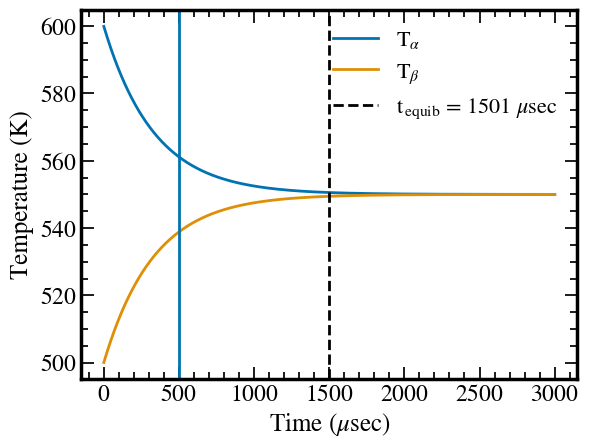

In [4]:
number_density = 3e23
mass = 6.6464764e-27
T_a0 = 600
T_b0 = 500
T_equib = (T_a0 + T_b0) / 2
sigma_0 = 1e-20
nu_col_inter = number_density * sigma_0
nu_col_intra = nu_col_inter * 100
dt = 1e-6
num_steps = 3000
t_final = dt * num_steps

def T_alpha_true(t, T_a=T_a0, T_b=T_b0, inter_nu=nu_col_inter):
  return (T_a + T_b) / 2 + (T_a - T_b) / 2 * np.exp(-inter_nu * t)

def T_beta_true(t, T_a=T_a0, T_b=T_b0, inter_nu=nu_col_inter):
  return (T_a + T_b) / 2 - (T_a - T_b) / 2 * np.exp(-inter_nu * t)

t_range = np.linspace(0, t_final, num_steps) + dt / 2
T_alpha_analytic = T_alpha_true(t_range)
T_beta_analytic = T_beta_true(t_range)
equib_idx = 1500
t_equib = t_range[equib_idx]

T_alpha_equib_idx = T_alpha_analytic[equib_idx]
T_alpha_equib_idx_error = np.abs(T_equib - T_alpha_equib_idx) / T_equib * 100
T_beta_equib_idx = T_beta_analytic[equib_idx]
T_beta_equib_idx_error = np.abs(T_equib - T_beta_equib_idx) / T_equib * 100
print("Percent  from Equilibrium")
print(f"T_alpha Error: { T_alpha_equib_idx_error :0.4f}%")
print(f"T_beta Error : { T_beta_equib_idx_error :0.4f}%")
plt.figure()
plt.plot(t_range * 1e6, T_alpha_analytic, label='T$_\\alpha$')
plt.plot(t_range * 1e6, T_beta_analytic, label='T$_\\beta$')
plt.axvline(t_equib * 1e6, c='k', linestyle='dashed', label=f't$_{{\\,\\text{{equib}}}}$ = {t_equib * 1e6:0.0f} $\\mu\\text{{sec}}$')
plt.axvline(t_range[500] * 1e6)
plt.ylabel("Temperature (K)")
plt.xlabel("Time ($\\mu$sec)")
plt.legend(loc='upper right')
plt.show()

In [5]:
def create_t_range_block(t_range, M, N_s):
    N_t = len(t_range)
    t_range_block = t_range
    for _ in range(M - 1):
      t_range_block = np.vstack((t_range_block, t_range))
    t_range_block = t_range_block.reshape((N_t, M))
    t_range_block_temp = t_range_block.copy()

    for _ in range(N_s - 1):
      t_range_block = np.dstack((t_range_block, t_range_block_temp))
    return t_range_block

In [6]:
def collect_data(N_p, species, num_points=3000):
  folder = f"{N_p:d}_ppe"
  files = glob.glob(f"{folder:s}/*{species:s}*.csv")
  temperature_data = None
  population_data = None
  temperature_cols = None
  population_cols = None
  t_range = None
  for i, f in enumerate( files ):
    data = pd.read_csv(f)
    if i == 0:
      column_names = data.columns
      temperature_cols = list(filter(lambda x: "T_" in x, column_names))
      population_cols = list(filter(lambda x: "N_" in x, column_names))
      temperature_data = data[temperature_cols].to_numpy()
      population_data = data[population_cols].to_numpy()
      t_range = data["t_vel"].to_numpy()
    else:
      curr_data = data[temperature_cols].to_numpy()
      temperature_data = np.dstack((temperature_data, curr_data))
      curr_data = data[population_cols].to_numpy()
      population_data = np.dstack((population_data, curr_data))
  return t_range, population_data, temperature_data

In [7]:
t_range_block = create_t_range_block(t_range, 16, 8)

T_a = T_alpha_true(t_range_block)
T_b = T_beta_true(t_range_block)

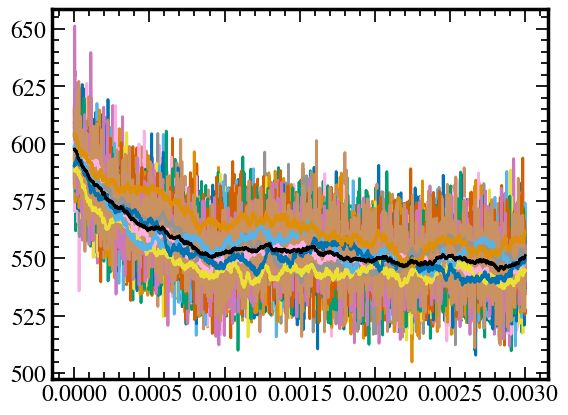

In [8]:
t_range, population_data, temperature_data = collect_data(256, "alpha")

N_t, M, N_s = temperature_data.shape

per_simulation_averages = temperature_data.mean(axis=1)
per_cell_averages = temperature_data.mean(axis=2)
total_average = per_cell_averages.mean(axis=1)


plt.figure()

for j in range(M):
  plt.plot(t_range, per_cell_averages[:, j])
for j in range(N_s):
  plt.plot(t_range, per_simulation_averages[:, j])

plt.plot(t_range, total_average, 'k')
plt.show()


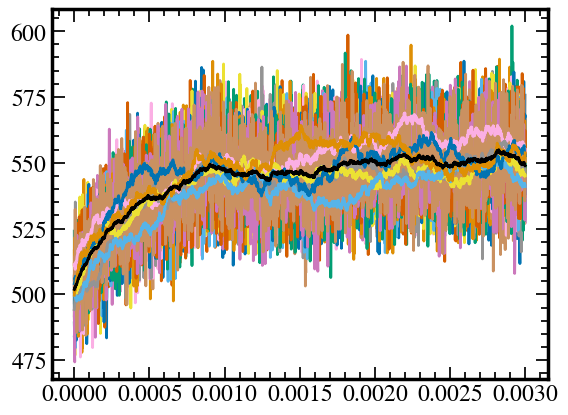

In [9]:


t_range, population_data, temperature_data = collect_data(256, "beta")

N_t, M, N_s = temperature_data.shape

per_simulation_averages = temperature_data.mean(axis=1)
per_cell_averages = temperature_data.mean(axis=2)
total_average = per_cell_averages.mean(axis=1)


plt.figure()

for j in range(M):
  plt.plot(t_range, per_cell_averages[:, j])
for j in range(N_s):
  plt.plot(t_range, per_simulation_averages[:, j])

plt.plot(t_range, total_average, 'k')
plt.show()


In [31]:
def calculate_errors(N_p):
  t_range, alpha_pop_data, T_alpha_data = collect_data(N_p, "alpha")
  _, beta_pop_data, T_beta_data = collect_data(N_p, "beta")
  _, M, N_s = alpha_pop_data.shape


  t_range_block = create_t_range_block(t_range, M, N_s)

  # T_alpha_rmse = ((T_alpha_data - T_alpha_analytic) / T_alpha_analytic)**2
  # T_beta_rmse = ((T_beta_data - T_beta_analytic) / T_beta_analytic)**2


  return t_range, T_alpha_data, alpha_pop_data, T_beta_data, beta_pop_data


In [32]:
ppe_vals = np.array([2**i for i in range(3, 9)])

t_ranges = []
alpha_pop_vals = []
T_alpha_vals = []
beta_pop_vals = []
T_beta_vals = []

for N_p in ppe_vals:
  print(f"PPE: {N_p:d}")
  t_range, T_alpha, alpha_pop, T_beta, beta_pop = calculate_errors(N_p)
  t_ranges.append(t_range)
  alpha_pop_vals.append(alpha_pop)
  T_alpha_vals.append(T_alpha)
  T_beta_vals.append(T_beta)
  beta_pop_vals.append(beta_pop)


PPE: 8
PPE: 16
PPE: 32
PPE: 64
PPE: 128
PPE: 256


In [77]:
for i, (a_pop, (b_pop, (T_a, T_b))) in enumerate(zip(alpha_pop_vals, zip(beta_pop_vals, zip(T_alpha_vals, T_beta_vals)))):
    T_a = T_a[:, :, :256]
    T_b = T_b[:, :, :256]
    a_pop = a_pop[:, :, :256]
    b_pop = b_pop[:, :, :256]
    T_alpha_vals[i] = T_a
    T_beta_vals[i] = T_b
    alpha_pop_vals[i] = a_pop
    beta_pop_vals[i] = b_pop


In [78]:
for i, (a_pop, (b_pop, (T_a, T_b))) in enumerate(zip(alpha_pop_vals, zip(beta_pop_vals, zip(T_alpha_vals, T_beta_vals)))):
    print(T_a.shape)
    print(a_pop.shape)
    print(T_b.shape)
    print(b_pop.shape)

(3000, 16, 256)
(3000, 16, 256)
(3000, 16, 256)
(3000, 16, 256)
(3000, 16, 127)
(3000, 16, 127)
(3000, 16, 127)
(3000, 16, 127)
(3000, 16, 64)
(3000, 16, 64)
(3000, 16, 64)
(3000, 16, 64)
(3000, 16, 32)
(3000, 16, 32)
(3000, 16, 32)
(3000, 16, 32)
(3000, 16, 15)
(3000, 16, 15)
(3000, 16, 15)
(3000, 16, 15)
(3000, 16, 6)
(3000, 16, 6)
(3000, 16, 6)
(3000, 16, 6)


0.0015005


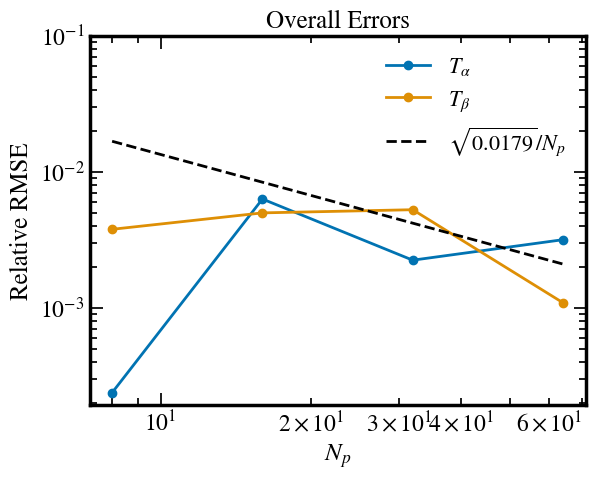

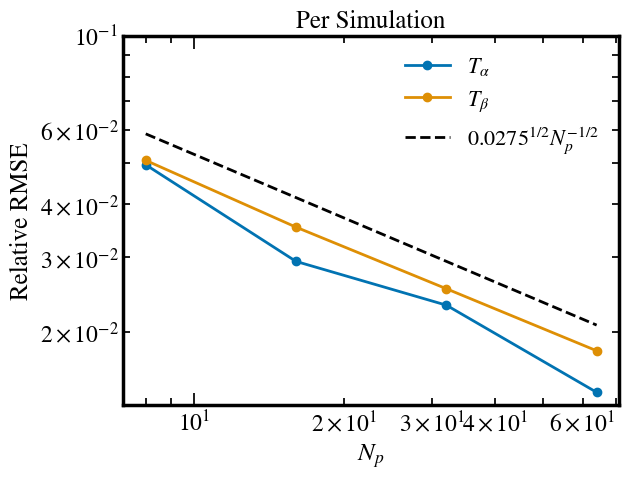

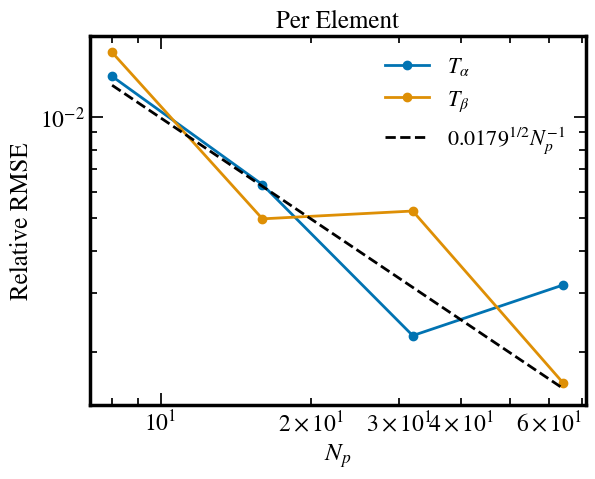

In [217]:
T_all_per_elem_errors = []
T_alpha_per_elem_errors = []
T_beta_per_elem_errors  = []
mean_per_elem_errors = []

T_all_per_sim_errors = []
T_alpha_per_sim_errors = []
T_beta_per_sim_errors  = []
mean_per_sim_errors = []

T_all_overall_errors = []
T_alpha_overall_errors = []
T_beta_overall_errors  = []
mean_overall_errors = []

t_range = t_ranges[0]
#

num_sims = np.zeros_like(ppe_vals, dtype=int)
# T_beta_analytic = T_beta_true(t_range_block)

M = 16

start_idx = 1500
end_idx = 3000
print(t_range[start_idx])
skips = 1
show_plots = False
for i, N_p in enumerate( ppe_vals ):
  _, _, N_s = T_alpha_vals[i].shape
  num_skips = int(2**8 / 2**(2 * i))
  num_sims[i] = N_s

  T_alpha_per_sim = (T_alpha_vals[i] * alpha_pop_vals[i]).sum(axis=1) / (M * N_p)
  T_beta_per_sim = (T_beta_vals[i] * beta_pop_vals[i]).sum(axis=1) / (M * N_p)
  T_all_per_sim = (T_alpha_per_sim + T_beta_per_sim) / 2

  T_alpha_per_elem = (T_alpha_vals[i] * alpha_pop_vals[i]).sum(axis=2) / (N_s * N_p)
  T_beta_per_elem = (T_beta_vals[i] * beta_pop_vals[i]).sum(axis=2) / (N_s * N_p)
  T_all_per_elem = (T_alpha_per_elem + T_beta_per_elem) / 2

  T_alpha_mean = T_alpha_per_sim.mean(axis=1)
  T_beta_mean = T_beta_per_sim.mean(axis=1)
  T_all_mean = T_all_per_sim.mean(axis=1)

  T_alpha_equib_overall_mean = T_alpha_per_sim[start_idx:end_idx:skips].mean(axis=0)
  T_beta_equib_overall_mean = T_beta_per_sim[start_idx:end_idx:skips].mean(axis=0)
  T_all_equib_overall_mean = T_all_per_sim[start_idx:end_idx:skips].mean(axis=0)

  T_alpha_equib_per_elem_mean = T_alpha_per_elem[start_idx:end_idx:skips].mean(axis=0)
  T_beta_equib_per_elem_mean = T_beta_per_elem[start_idx:end_idx:skips].mean(axis=0)
  T_all_equib_per_elem_mean = T_all_per_elem[start_idx:end_idx:skips].mean(axis=0)

  if show_plots:
    plt.figure()
    plt.title("Per Elemen Over all Sims")
    plt.plot(t_range, T_alpha_per_elem)
    plt.plot(t_range, T_beta_per_elem)
    plt.axhline(T_equib)
    plt.show()

    plt.figure()
    plt.title("Per sim mean")
    plt.plot(t_range, T_alpha_per_sim)
    plt.plot(t_range, T_beta_per_sim)
    plt.axhline(T_equib)
    plt.show()

    plt.figure()
    plt.title("Overall mean")
    plt.plot(t_range, T_alpha_mean)
    plt.plot(t_range, T_beta_mean)
    plt.axhline(T_equib)
    plt.show()

  T_equib = (T_a0 + T_b0) / 2
#   T_equib = (T_alpha_equib_overall_mean + T_beta_equib_overall_mean).mean() / 2

#   T_alpha_overall_errors.append(np.sqrt(((T_alpha_equib_overall_mean.mean() - T_equib) / T_equib)**2))
#   T_beta_overall_errors.append(np.sqrt(((T_beta_equib_overall_mean.mean() - T_equib) / T_equib)**2))
#   T_all_overall_errors.append(np.sqrt(((T_all_equib_overall_mean.mean() - T_equib) / T_equib)**2))
#   mean_overall_errors.append(np.sqrt((T_alpha_overall_errors[-1]**2 + T_beta_overall_errors[-1]**2) / 2))

#   T_alpha_per_sim_errors.append(np.sqrt((((T_alpha_equib_overall_mean - T_equib) / T_equib)**2).sum() / N_s))
#   T_beta_per_sim_errors.append(np.sqrt((((T_beta_equib_overall_mean - T_equib) / T_equib)**2).sum() / N_s))
#   T_all_per_sim_errors.append(np.sqrt((((T_all_equib_overall_mean - T_equib) / T_equib)**2).sum() / N_s))
#   mean_per_sim_errors.append(np.sqrt((T_alpha_per_sim_errors[-1]**2 + T_beta_per_sim_errors[-1]**2) / 2))

#   T_alpha_per_elem_errors.append(np.sqrt((((T_alpha_equib_per_elem_mean - T_equib) / T_equib)**2).sum() / M))
#   T_beta_per_elem_errors.append(np.sqrt((((T_beta_equib_per_elem_mean - T_equib) / T_equib)**2).sum() / M))
#   T_all_per_elem_errors.append(np.sqrt((((T_all_equib_per_elem_mean - T_equib) / T_equib)**2).sum() / N_s))
#   mean_per_elem_errors.append(np.sqrt((T_alpha_per_elem_errors[-1]**2 + T_beta_per_elem_errors[-1]**2) / 2))

  T_alpha_overall_errors.append(np.abs(T_alpha_equib_overall_mean.mean() - T_equib) / T_equib)
  T_beta_overall_errors.append(np.abs(T_beta_equib_overall_mean.mean() - T_equib) / T_equib)
  T_all_overall_errors.append(np.abs(T_all_equib_overall_mean.mean() - T_equib) / T_equib)
  mean_overall_errors.append((T_alpha_overall_errors[-1] + T_beta_overall_errors[-1]) /2)

  T_alpha_per_sim_errors.append(((np.abs(T_alpha_equib_overall_mean - T_equib) / T_equib)).sum() / N_s)
  T_beta_per_sim_errors.append(((np.abs(T_beta_equib_overall_mean - T_equib) / T_equib)).sum() / N_s)
  T_all_per_sim_errors.append(((np.abs(T_all_equib_overall_mean - T_equib) / T_equib)).sum() / N_s)
  mean_per_sim_errors.append((T_alpha_per_sim_errors[-1] + T_beta_per_sim_errors[-1]) / 2)

  T_alpha_per_elem_errors.append(((np.abs(T_alpha_equib_per_elem_mean - T_equib) / T_equib).sum() / M))
  T_beta_per_elem_errors.append((((np.abs(T_beta_equib_per_elem_mean - T_equib) / T_equib)).sum() / M))
  T_all_per_elem_errors.append((((np.abs(T_all_equib_per_elem_mean - T_equib) / T_equib)).sum() / N_s))
  mean_per_elem_errors.append(((T_alpha_per_elem_errors[-1] + T_beta_per_elem_errors[-1]) / 2))




plt.figure()
plt.title("Overall Errors")
# plt.loglog(ppe_vals, T_all_overall_errors, '-o', label='All')
plt.loglog(ppe_vals[:4], T_alpha_overall_errors[:4], '-o', label='$T_\\alpha$')
plt.loglog(ppe_vals[:4], T_beta_overall_errors[:4], '-o', label='$T_\\beta$')
# plt.loglog(ppe_vals, mean_overall_errors, '-o', label='Mean')
plt.loglog(ppe_vals[:4], np.sqrt(0.0179) / ppe_vals[:4], '--k', label="$\\sqrt{0.0179} / N_p$")
plt.xlabel("$N_p$")
plt.ylabel("Relative RMSE")
plt.legend(loc='upper right')
plt.ylim(top=1e-1)
plt.show()

plt.figure()
plt.title("Per Simulation")
# plt.loglog(ppe_vals, T_all_per_sim_errors, '-o', label='All')
plt.loglog(ppe_vals[:4], T_alpha_per_sim_errors[:4], '-o', label='$T_\\alpha$')
plt.loglog(ppe_vals[:4], T_beta_per_sim_errors[:4], '-o', label='$T_\\beta$')
# plt.loglog(ppe_vals, mean_per_sim_errors, '-o', label='Mean')
plt.loglog(ppe_vals[:4], np.sqrt(0.0275) / np.sqrt(ppe_vals[:4]),'--k',  label="$0.0275^{1/2}N_p^{-1/2}$")
plt.xlabel("$N_p$")
plt.ylabel("Relative RMSE")
plt.legend(loc='upper right')
plt.ylim(top=1e-1)
plt.savefig("temperature_per_simulation.png", format="png")
plt.show()

plt.figure()
plt.title("Per Element")
# plt.loglog(ppe_vals, T_all_per_elem_errors, '-o', label='All')
plt.loglog(ppe_vals[:4], T_alpha_per_elem_errors[:4], '-o', label='$T_\\alpha$')
plt.loglog(ppe_vals[:4], T_beta_per_elem_errors[:4], '-o', label='$T_\\beta$')
plt.loglog(ppe_vals[:4], np.sqrt(0.0099) / ppe_vals[:4], '--k', label="$0.0179^{1/2} N_p^{-1}$")
plt.xlabel("$N_p$")
plt.ylabel("Relative RMSE")
plt.legend(loc='upper right')
# plt.ylim(top=1e-2)
plt.savefig("temperature_per_element.png", format="png")
plt.show()


In [13]:
initialization = pd.read_csv("initialization_alpha/4_ppe.csv")
t_columns = list(filter(lambda x : "T" in x,  initialization.columns))

temperatures = initialization[t_columns].to_numpy()

In [19]:
sublabel_x = 0.96
sublabel_y = 0.1

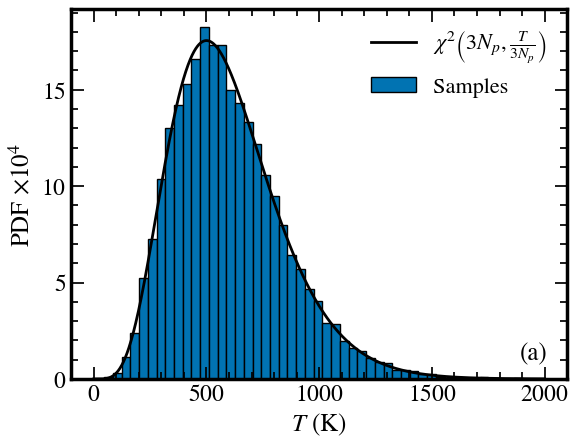

In [175]:

T_hist = np.histogram(temperatures.flatten(), bins=50, density=True)
T_vals = T_hist[0]
T_centers = (T_hist[1][1:] + T_hist[1][:-1]) / 2
T_widths = T_hist[1][1:] - T_hist[1][:-1]

M = 16
N_p = 4
T_a0 = 600
x_range = np.linspace(0, 2000, 1000)
_, ax = plt.subplots()
plt.bar(
    T_centers,
    1e4 * T_vals,
    T_widths,
    edgecolor="k",
    label="Samples",
)
plt.plot(x_range, 1e4 * stats.chi2.pdf(x_range, df=3 * N_p, scale=T_a0 / (3 * N_p)), 'k', label='$\\chi^2 \\left( 3 N_p, \\frac{T}{3 N_p} \\right)$')
plt.ylabel("PDF $\\times 10^4$")
plt.legend(loc='upper right')
plt.xlabel("$T$ (K)")
ax.text(sublabel_x, sublabel_y, '(a)', transform=ax.transAxes,fontsize=18, ha='right', va='top')
plt.savefig("initialization_alpha/per_element.png", format="png")
plt.show()

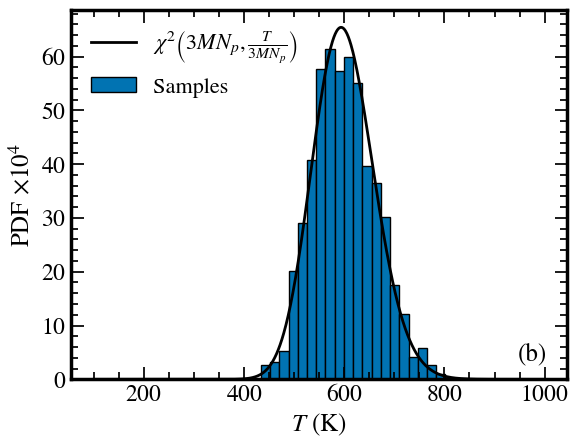

In [176]:

T_hist = np.histogram(temperatures.mean(axis=1).flatten(), bins=20, density=True)
T_vals = T_hist[0]
T_centers = (T_hist[1][1:] + T_hist[1][:-1]) / 2
T_widths = T_hist[1][1:] - T_hist[1][:-1]

M = 16
N_p = 4
T_a0 = 600
x_range = np.linspace(100, 1000, 1000)
_, ax = plt.subplots()
plt.bar(
    T_centers,
    1e4 * T_vals,
    T_widths,
    edgecolor="k",
    label="Samples",
)
plt.plot(x_range, 1e4 * stats.chi2.pdf(x_range, df=3 * N_p * M, scale=T_a0 / (3 * N_p * M)), 'k', label='$\\chi^2 \\left( 3 M N_p, \\frac{T}{3 M N_p} \\right)$')
plt.ylabel("PDF $\\times 10^4$")
plt.legend(loc='upper left')
plt.xlabel("$T$ (K)")
ax.text(sublabel_x, sublabel_y, '(b)', transform=ax.transAxes,fontsize=18, ha='right', va='top')
plt.savefig("initialization_alpha/per_domain.png", format="png")
plt.show()